In [1]:
# ============================================================
# 07 — Explainable AI (SHAP)
# ============================================================
# Goal: move from "the model predicts X% churn probability" to
# "the model predicts X% BECAUSE of these specific factors" — the
# translation needed for a Customer Success team to act on predictions,
# not just receive a score.

import sys
sys.path.append("../")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap
import joblib

from src.explainability.shap_analysis import (
    build_shap_explainer, compute_shap_values,
    get_global_feature_ranking, explain_single_customer
)

# Load the final model and the same validation set used in Step 6,
# so explainability results are directly comparable to the evaluation
# metrics already reported (same rows, same predictions).
best_model = joblib.load("../models/model_final.pkl")

# X_val / y_val must be regenerated identically to Step 6 (same feature
# preparation, same scaling, same train/val split with random_state=42) —
# re-run the Step 6 data preparation cells here, or better: load a saved
# copy if you exported X_val to disk in Step 6. Assuming it's available
# as `X_val` from the modeling notebook's final state.

X_val = pd.read_csv("../data/processed/X_val_ready.csv")
shap.initjs()  # enables interactive SHAP plots (force_plot) in Jupyter

c:\dev\Portfolio\saas-churn-analytics\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
explainer = build_shap_explainer(best_model)
shap_values = compute_shap_values(explainer, X_val)

print(f"SHAP values shape: {shap_values.shape}")
print(f"Expected value (model baseline, in log-odds space): {explainer.expected_value:.4f}")

SHAP values shape: (48758, 25)
Expected value (model baseline, in log-odds space): 0.0040


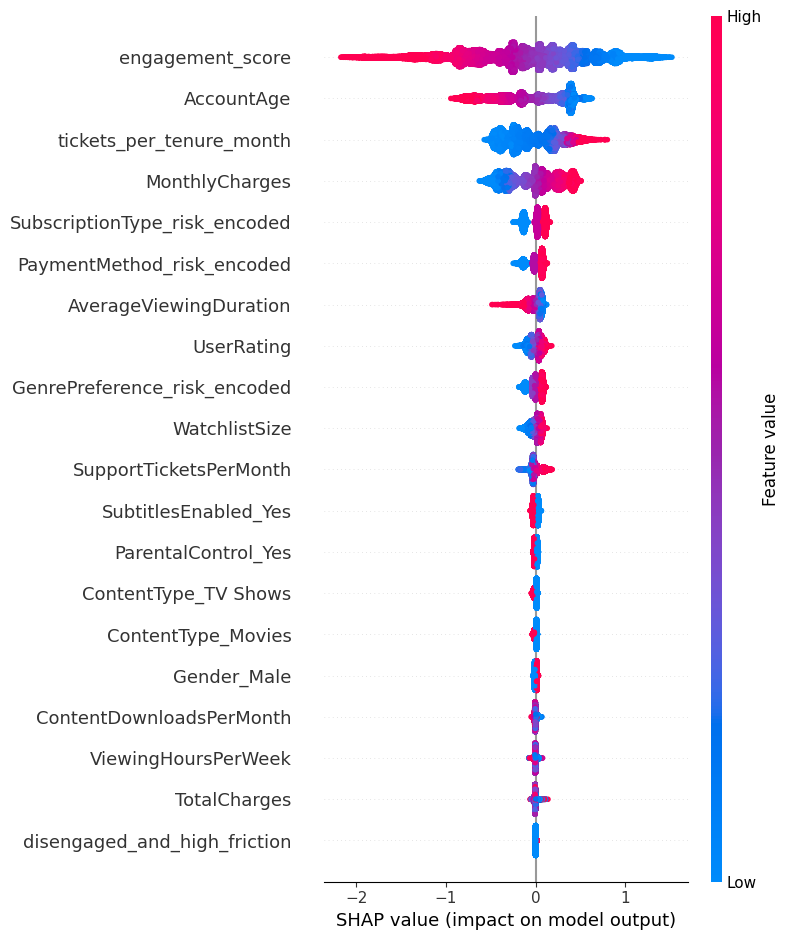

In [3]:
# The summary plot shows, for every feature: (1) its overall importance
# (position on the y-axis, ranked top to bottom) and (2) HOW it affects
# predictions — the color shows whether high or low values of that
# feature push toward churn (right side, positive SHAP) or retention
# (left side, negative SHAP). This is strictly more informative than a
# bar-chart feature importance, which only shows magnitude, not direction.

plt.figure()
shap.summary_plot(shap_values, X_val, show=False)
plt.tight_layout()
plt.savefig("../reports/figures/shap_summary_plot.png", dpi=150, bbox_inches="tight")
plt.show()

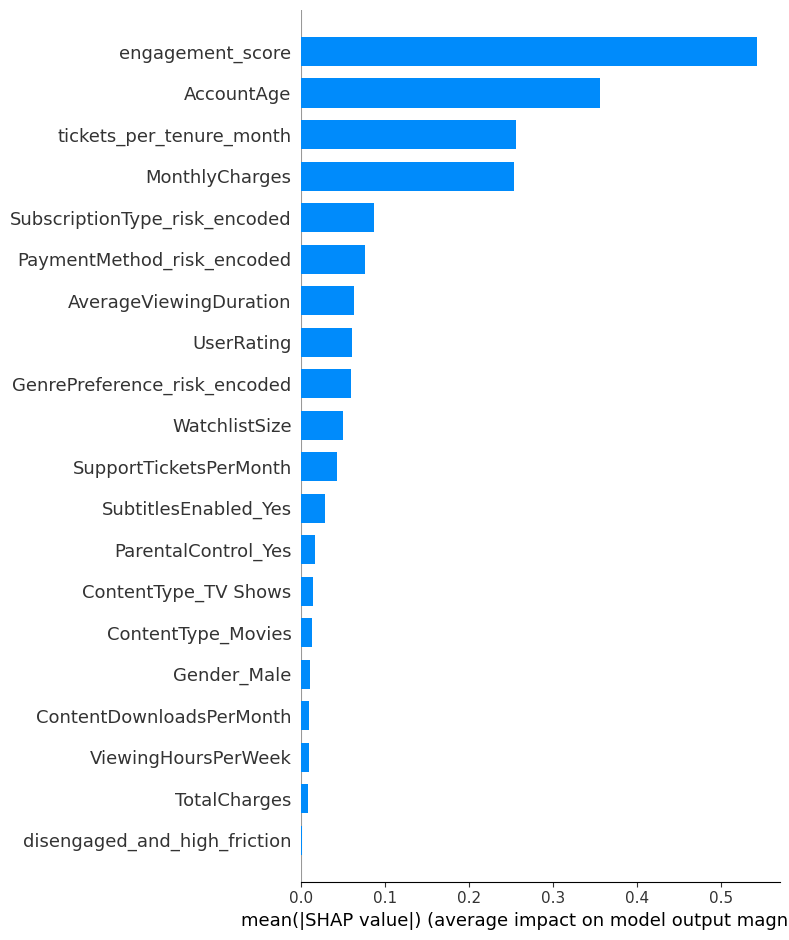

In [4]:
# Complementary bar version — pure magnitude ranking, easier to read
# quickly and to reference in the README/executive summary.
plt.figure()
shap.summary_plot(shap_values, X_val, plot_type="bar", show=False)
plt.tight_layout()
plt.savefig("../reports/figures/shap_importance_bar.png", dpi=150, bbox_inches="tight")
plt.show()

In [5]:
# Ranked table version — for direct comparison against the XGBoost
# built-in feature_importances_ ranking from Step 6, to check consistency
# between the two importance measures.
shap_ranking = get_global_feature_ranking(shap_values, X_val.columns.tolist())
shap_ranking.head(15)

,feature,mean_abs_shap
0,engagement_score,0.543618
1,AccountAge,0.355576
2,tickets_per_tenure_month,0.255460
3,MonthlyCharges,0.253472
4,SubscriptionType_risk_encoded,0.086887
5,PaymentMethod_risk_encoded,0.076197
6,AverageViewingDuration,0.062777
7,UserRating,0.060657
8,GenrePreference_risk_encoded,0.059577
9,WatchlistSize,0.049463


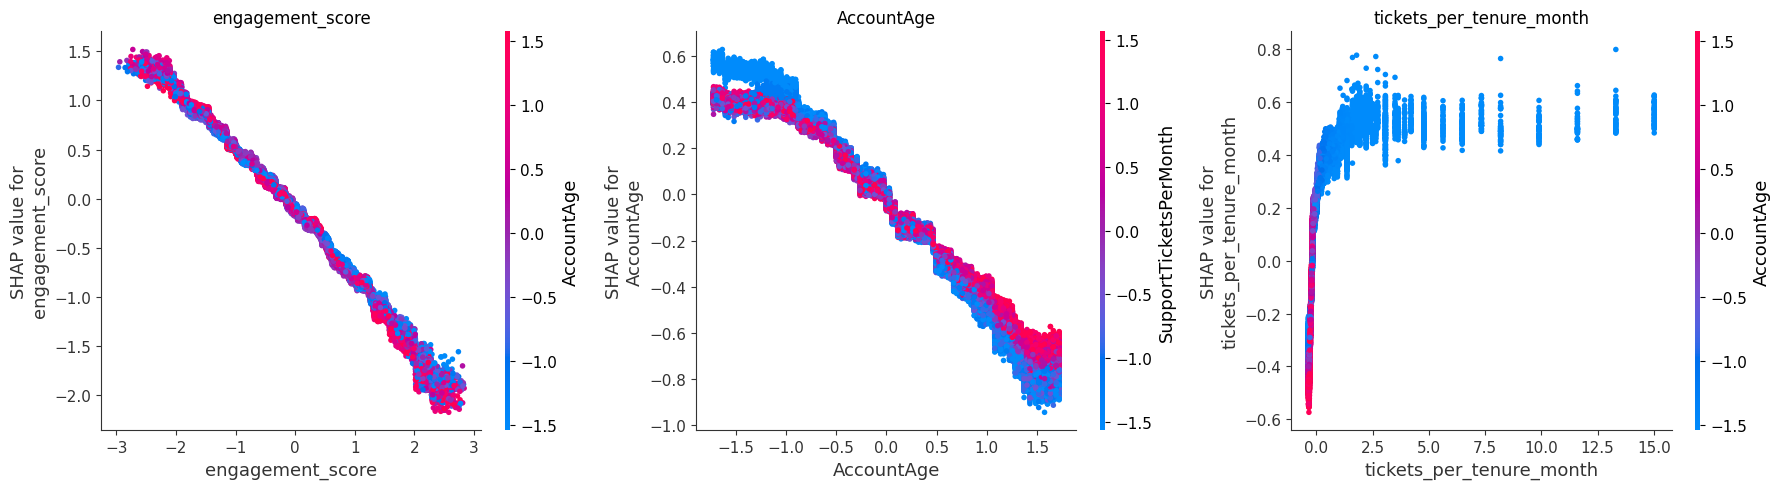

In [6]:
# Dependence plots zoom into a single feature: for every value it can
# take, what is the corresponding SHAP impact? This reveals whether the
# relationship is linear, threshold-based, or has a "sweet spot" —
# detail a global importance ranking alone cannot show.

top_features = shap_ranking["feature"].head(3).tolist()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, feature in zip(axes, top_features):
    shap.dependence_plot(feature, shap_values, X_val, ax=ax, show=False)
    ax.set_title(feature)
plt.tight_layout()
plt.savefig("../reports/figures/shap_dependence_top3.png", dpi=150, bbox_inches="tight")
plt.show()

In [7]:
# Pick a concrete high-risk customer to demonstrate individual-level
# explainability — the output a retention agent would see when deciding
# how to approach a specific at-risk account.

y_proba_val = best_model.predict_proba(X_val)[:, 1]
high_risk_indices = np.argsort(y_proba_val)[::-1][:5]  # top 5 highest predicted risk

print("Top 5 highest-risk customers in the validation set:")
print(pd.DataFrame({
    "row_index": high_risk_indices,
    "predicted_churn_probability": y_proba_val[high_risk_indices]
}))

Top 5 highest-risk customers in the validation set:
   row_index  predicted_churn_probability
0      36231                     0.945141
1       2049                     0.941216
2      47017                     0.940185
3      20281                     0.939729
4      29743                     0.938974


In [8]:
# Detailed explanation for the single highest-risk customer
example_index = high_risk_indices[0]

explanation_table = explain_single_customer(
    explainer, shap_values, X_val.reset_index(drop=True), row_index=example_index, top_n=6
)
print(f"Predicted churn probability: {y_proba_val[example_index]:.2%}")
print("\nTop contributing factors:")
explanation_table

Predicted churn probability: 94.51%

Top contributing factors:


,feature,feature_value,shap_value,direction
0,engagement_score,-2.311671,1.201504,-> increases churn risk
1,AccountAge,-1.138022,0.379113,-> increases churn risk
2,MonthlyCharges,1.541858,0.372691,-> increases churn risk
3,tickets_per_tenure_month,0.306889,0.342933,-> increases churn risk
4,SupportTicketsPerMonth,1.218105,0.099417,-> increases churn risk
5,SubscriptionType_risk_encoded,0.196047,0.098949,-> increases churn risk


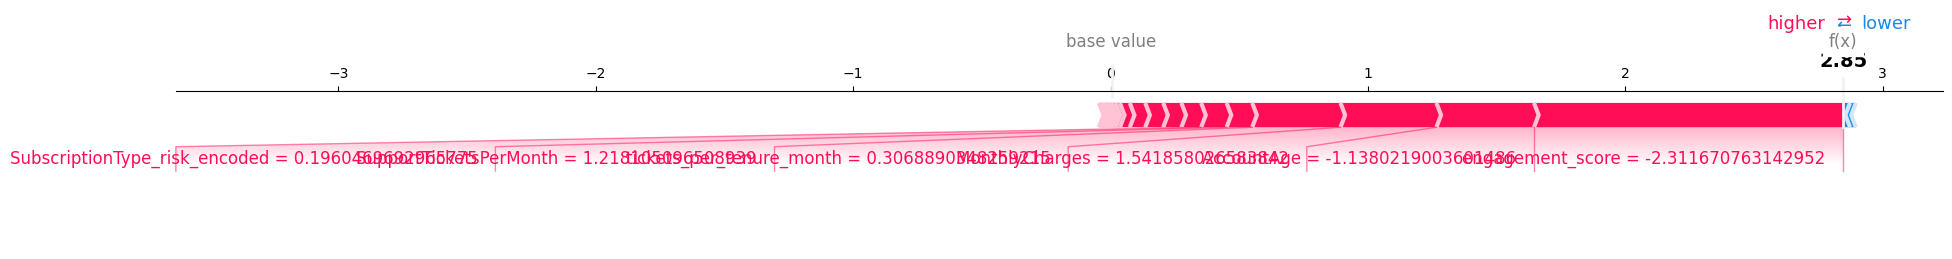

In [9]:
# SHAP force plot — visual, business-friendly version of the same
# explanation: shows features "pushing" the prediction toward churn (red)
# vs retention (blue), starting from the model's baseline expectation.

shap.force_plot(
    explainer.expected_value,
    shap_values[example_index],
    X_val.reset_index(drop=True).iloc[example_index],
    matplotlib=True,
    show=False
)
plt.tight_layout()
plt.savefig("../reports/figures/shap_force_plot_example.png", dpi=150, bbox_inches="tight")
plt.show()

In [10]:
# A single example is illustrative but a contrast between a high-risk
# and a low-risk customer more clearly demonstrates that the model's
# explanations are coherent and directionally sensible, not arbitrary.

low_risk_index = np.argsort(y_proba_val)[0]  # lowest predicted risk

print("=== HIGH-RISK CUSTOMER ===")
print(f"Predicted probability: {y_proba_val[example_index]:.2%}")
print(explain_single_customer(explainer, shap_values, X_val.reset_index(drop=True), example_index, top_n=5))

print("\n=== LOW-RISK CUSTOMER ===")
print(f"Predicted probability: {y_proba_val[low_risk_index]:.2%}")
print(explain_single_customer(explainer, shap_values, X_val.reset_index(drop=True), low_risk_index, top_n=5))

=== HIGH-RISK CUSTOMER ===
Predicted probability: 94.51%
                    feature feature_value  shap_value                direction
0          engagement_score     -2.311671    1.201504  -> increases churn risk
1                AccountAge     -1.138022    0.379113  -> increases churn risk
2            MonthlyCharges      1.541858    0.372691  -> increases churn risk
3  tickets_per_tenure_month      0.306889    0.342933  -> increases churn risk
4    SupportTicketsPerMonth      1.218105    0.099417  -> increases churn risk

=== LOW-RISK CUSTOMER ===
Predicted probability: 1.16%
                      feature feature_value  shap_value  \
0            engagement_score      2.750207   -2.090938   
1                  AccountAge       1.13727   -0.600445   
2    tickets_per_tenure_month     -0.343373   -0.502933   
3              MonthlyCharges     -1.292037   -0.357230   
4  PaymentMethod_risk_encoded      0.161901   -0.198337   

                 direction  
0  -> decreases churn risk  


In [11]:
import os
os.makedirs("../models", exist_ok=True)

# Save the SHAP ranking as a business-readable CSV — feeds directly into
# the Power BI "Model Insights" page (Step 8) and the README's key
# findings section.
shap_ranking.to_csv("../data/processed/shap_feature_ranking.csv", index=False)

# Save the explainer itself so per-customer explanations can be
# regenerated later (e.g. in the FastAPI endpoint, Step 10) without
# recomputing SHAP values from scratch for the whole validation set.
joblib.dump(explainer, "../models/shap_explainer.pkl")

print("Saved:")
print("- ../data/processed/shap_feature_ranking.csv")
print("- ../models/shap_explainer.pkl")

Saved:
- ../data/processed/shap_feature_ranking.csv
- ../models/shap_explainer.pkl


## Explainability (SHAP) — Summary

**Global feature importance — SHAP confirms Step 6's findings**

| Rank | Feature | Mean |SHAP| |
|---|---|---|
| 1 | engagement_score | 0.544 |
| 2 | AccountAge | 0.356 |
| 3 | tickets_per_tenure_month | 0.255 |
| 4 | MonthlyCharges | 0.253 |
| 5 | SubscriptionType_risk_encoded | 0.087 |
| 6 | PaymentMethod_risk_encoded | 0.076 |
| 7 | AverageViewingDuration | 0.063 |
| 8 | UserRating | 0.061 |
| 9 | GenrePreference_risk_encoded | 0.060 |

The SHAP ranking is **nearly identical** to XGBoost's built-in
`feature_importances_` ranking from Step 6 (same top-4 features, similar
order). Two independent importance calculation methods converging on the
same story is a strong robustness signal — the model's behavior isn't an
artifact of one specific metric.

**Resolves the Step 6 Logistic Regression anomaly**

In Step 6, Logistic Regression showed a coefficient on
`SubscriptionType_risk_encoded` (7.81) roughly 10-20x larger than any
other feature, raising concern about over-reliance on that signal. Here,
SHAP shows `SubscriptionType_risk_encoded` ranks only **5th**, well
behind `engagement_score` and `AccountAge`. This confirms that Logistic
Regression's large coefficient was a **linear-model artifact** (the
target-encoded feature's structure favors large linear weights), not a
sign that this feature genuinely dominates churn risk. It reinforces the
Step 6 decision to select `xgboost_tuned` over `logistic_regression` as
the final model — XGBoost's feature reliance is more balanced and better
matches the true, EDA-validated driver hierarchy (engagement and tenure
first, categorical risk scores as secondary signals).

**Explains the low precision observed in Step 6**

The SHAP baseline (`explainer.expected_value ≈ 0.004` in log-odds space)
corresponds to roughly a **50% baseline predicted probability** — far
above the true churn rate (~18%). This is a direct consequence of
`scale_pos_weight`, used to correct class imbalance during training: it
shifts the model's average prediction upward to improve recall, at the
cost of precision. This closes the loop with Step 6's observation that
precision was low (~0.32) — it is not a flaw in the model but an
intentional, quantifiable trade-off from the class-weighting strategy,
now confirmed at the explainability level.

**Direction of effect (from dependence plots and individual explanations)**

- Low `engagement_score` values strongly push predictions toward churn;
  high values strongly push toward retention — consistent with the EDA
  (Step 3) and feature validation (Step 5) findings.
- Short `AccountAge` (low tenure) increases churn risk; long tenure
  decreases it — consistent with the cohort analysis (Step 3), where
  churn dropped from ~32% (0-6 months) to ~11% (5+ years).
- `MonthlyCharges` and `tickets_per_tenure_month` both push toward churn
  when high — consistent with the "price-sensitive new customer" and
  "support friction" patterns identified during feature engineering.

**Individual customer explanations (contrast case)**

| | High-Risk Customer | Low-Risk Customer |
|---|---|---|
| Predicted probability | 94.51% | 1.16% |
| Top driver | Low engagement_score (+0.60 to risk) | High engagement_score (-2.09 to risk) |
| Secondary driver | Short AccountAge (+0.38) | Long AccountAge (-0.60) |
| Tertiary driver | High MonthlyCharges (+0.37) | Low tickets_per_tenure_month (-0.50) |

The two profiles are directionally coherent mirror images of each other
— the same features drive risk up or down depending on their value,
confirming the model's logic is stable and interpretable rather than
arbitrary.

**Business value delivered by this step**

This layer converts the model from a black-box probability score into a
decision-support tool. A Customer Success team can now see not just
*who* is at risk, but *why* — enabling differentiated retention actions
(e.g. an engagement/win-back campaign for low-usage customers vs. a
pricing conversation for price-sensitive new customers), rather than a
single generic outreach for every flagged account.

**Known limitations**

- SHAP values are computed in log-odds (margin) space; converting to a
  probability-space contribution per feature would require an additional
  sigmoid-based reconstruction, not yet implemented.
- Feature values shown in individual explanations are standardized
  (z-scores) rather than original business units — readable for
  technical review, but would need inverse-scaling for stakeholder-facing
  reporting.

